In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# For CNN models
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
model1 = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(x_train, y_train,
                      epochs=5,
                      validation_data=(x_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8766 - loss: 0.4344 - val_accuracy: 0.9610 - val_loss: 0.1361
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9629 - loss: 0.1269 - val_accuracy: 0.9675 - val_loss: 0.1031
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9770 - loss: 0.0796 - val_accuracy: 0.9761 - val_loss: 0.0793
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9837 - loss: 0.0555 - val_accuracy: 0.9773 - val_loss: 0.0735
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9871 - loss: 0.0432 - val_accuracy: 0.9783 - val_loss: 0.0710


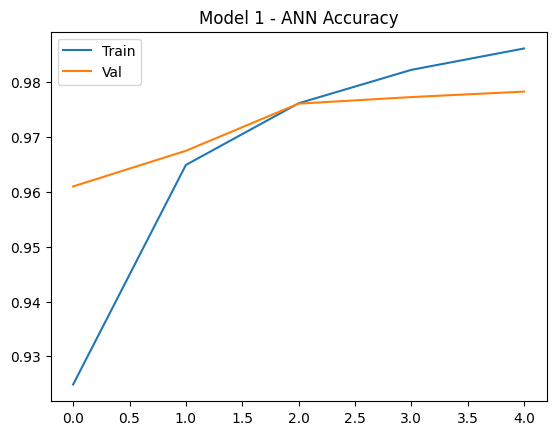

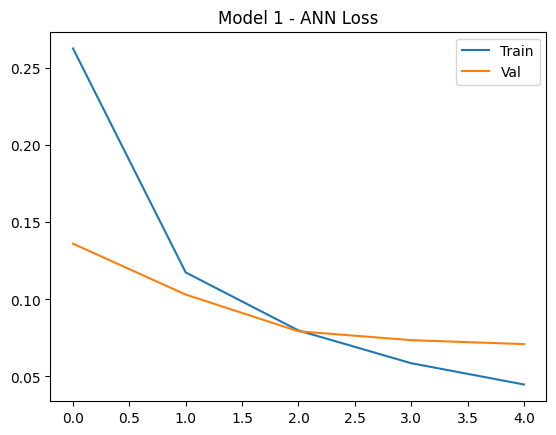

In [4]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title("Model 1 - ANN Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title("Model 1 - ANN Loss")
plt.legend(['Train','Val'])
plt.show()

In [5]:
model2 = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(x_train_cnn, y_train,
                      epochs=5,
                      validation_data=(x_test_cnn, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9028 - loss: 0.3319 - val_accuracy: 0.9779 - val_loss: 0.0719
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9823 - loss: 0.0590 - val_accuracy: 0.9823 - val_loss: 0.0510
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9825 - val_loss: 0.0523
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9874 - val_loss: 0.0412
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 0.9865 - val_loss: 0.0443


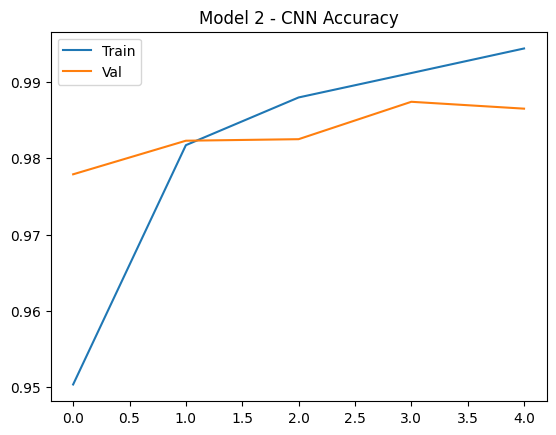

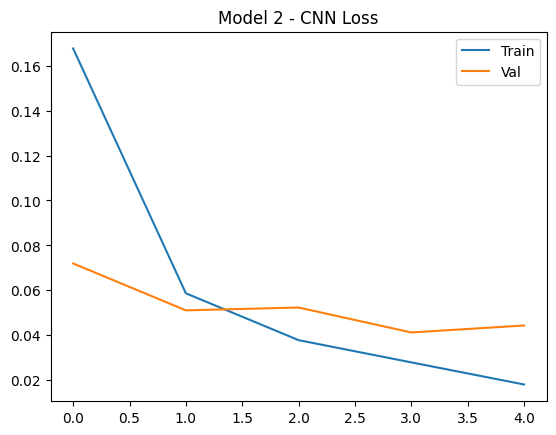

In [8]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title("Model 2 - CNN Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title("Model 2 - CNN Loss")
plt.legend(['Train','Val'])
plt.show()

In [9]:
model3 = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

model3.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(x_train_cnn, y_train,
                      epochs=5,
                      validation_data=(x_test_cnn, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.8082 - loss: 0.6068 - val_accuracy: 0.9735 - val_loss: 0.0860
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9446 - loss: 0.1835 - val_accuracy: 0.9799 - val_loss: 0.0645
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9578 - loss: 0.1445 - val_accuracy: 0.9816 - val_loss: 0.0540
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9625 - loss: 0.1205 - val_accuracy: 0.9829 - val_loss: 0.0515
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9672 - loss: 0.1053 - val_accuracy: 0.9864 - val_loss: 0.0430


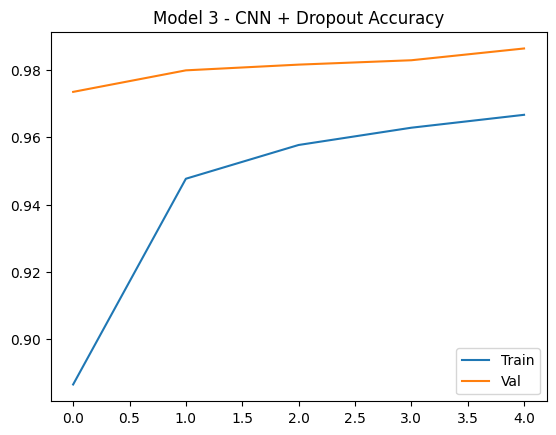

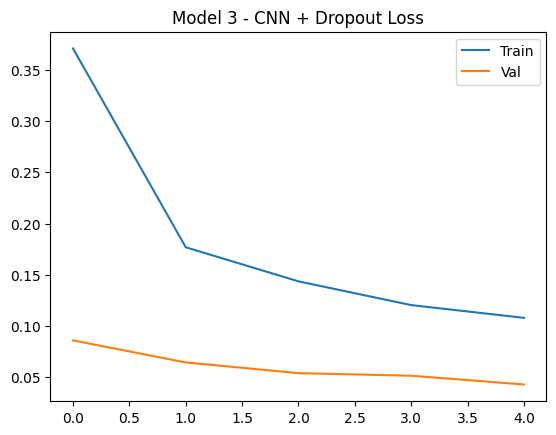

In [10]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title("Model 3 - CNN + Dropout Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title("Model 3 - CNN + Dropout Loss")
plt.legend(['Train','Val'])
plt.show()

In [11]:
model4 = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model4.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history4 = model4.fit(x_train_cnn, y_train,
                      epochs=5,
                      validation_data=(x_test_cnn, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 155s 82ms/step - accuracy: 0.9302 - loss: 0.2302 - val_accuracy: 0.9847 - val_loss: 0.0466
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 159s 85ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9876 - val_loss: 0.0363
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 202s 85ms/step - accuracy: 0.9938 - loss: 0.0195 - val_accuracy: 0.9890 - val_loss: 0.0309
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 158s 84ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.9904 - val_loss: 0.0322
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 158s 84ms/step - accuracy: 0.9970 - loss: 0.0085 - val_accuracy: 0.9888 - val_loss: 0.0391


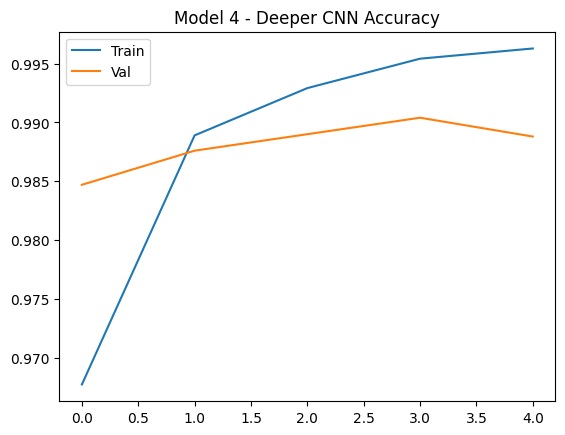

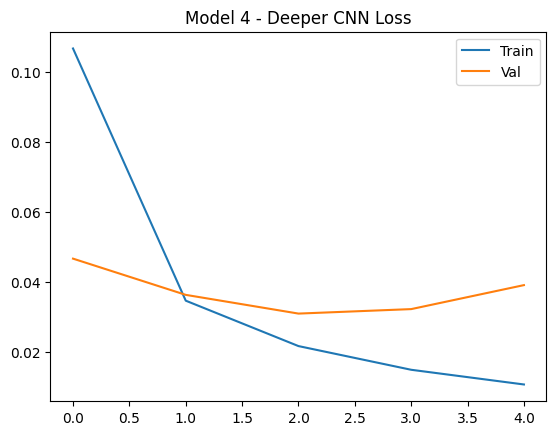

In [13]:
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.title("Model 4 - Deeper CNN Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title("Model 4 - Deeper CNN Loss")
plt.legend(['Train','Val'])
plt.show()